In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score
import os, glob, re


from sklearn.model_selection import KFold

# Training and validation data

In [8]:
# ---------------------------------------------------------------------------
# IMMREP25 -> per-epitope folders + validation.csv (pipeline format).
#   V: inferred from CDR1/CDR2  (name column used only to validate family)
#   J: taken from the name column, normalized to IMGT
#      (soft-checked against the CDR3 3' end, allowing J-trimming; flag only)
#   HLA de-alleled (A*02:01 -> A0201). `dataset_source` dropped.
# ---------------------------------------------------------------------------
IMMREP_TSV = 'IMMREP25/immrep2025_for_release.tsv'
OUT_DIR    = 'IMMREP25'
REF_DIR    = '/Users/roessner/Documents/PostDoc/Data/MixTCRviz/data_raw/CDR123/HomoSapiens'

ungap = lambda s: re.sub('[^A-Z]', '', str(s).upper())        # strip alignment gaps ('-')

def _ref(gene_type):
    df = pd.read_csv(f'{REF_DIR}/{gene_type}.csv')
    return df.rename(columns={df.columns[0]: 'name'})

# V: (CDR1, CDR2) -> [IMGT names]
V_LUT = {}
for chain, gt in [('A', 'TRAV'), ('B', 'TRBV')]:
    lut = {}
    for _, r in _ref(gt).iterrows():
        lut.setdefault((ungap(r['CDR1']), ungap(r['CDR2'])), []).append(r['name'])
    V_LUT[chain] = lut

# J: valid IMGT names + germline CDR3 3' suffix per gene
J_NAMES  = {'A': set(_ref('TRAJ')['name']), 'B': set(_ref('TRBJ')['name'])}
J_SUFFIX = {c: {r['name']: ungap(r['CDR3']) for _, r in _ref(gt).iterrows()}
            for c, gt in [('A', 'TRAJ'), ('B', 'TRBJ')]}

# ---- converters ------------------------------------------------------------
def resolve_v(chain, cdr1, cdr2, imm_name):
    """IMGT V name from CDR1/CDR2 (robust to '-X'/ambiguous names); None if no match."""
    cands = V_LUT[chain].get((ungap(cdr1), ungap(cdr2)))
    if not cands:
        return None
    cands = [c for c in cands if 'OR' not in c] or cands        # drop orphons on collision
    if len(cands) == 1:
        return cands[0]
    m = re.match(r'TCR[AB]V\d+-(\d+)', imm_name)                 # TRBV6-2 vs 6-3: use the name
    if m:
        want = f'-{int(m.group(1))}'
        for c in cands:
            if c.endswith(want):
                return c
    return cands[0]

def convert_j(chain, j_name):
    """TCRBJ01-01 -> TRBJ1-1 ; TCRAJ39-01 -> TRAJ39 (whichever exists in the reference)."""
    m = re.match(r'TCR[AB]J(\d+)-(\d+)', j_name)
    fam, mem = int(m.group(1)), int(m.group(2))
    for cand in (f'TR{chain}J{fam}-{mem}', f'TR{chain}J{fam}'):
        if cand in J_NAMES[chain]:
            return cand
    return None

fmt_hla = lambda h: h.replace('*', '').replace(':', '')         # A*02:01 -> A0201

# ---- build the pipeline table ----------------------------------------------
imm = pd.read_csv(IMMREP_TSV, sep='\t')

val = pd.DataFrame({
    'model'   : imm['hla'].map(fmt_hla) + '_' + imm['peptide'],
    'TRAV'    : [resolve_v('A', c1, c2, v) for c1, c2, v in zip(imm['tcra_cdr1'], imm['tcra_cdr2'], imm['tcra_v'])],
    'TRAJ'    : [convert_j('A', j) for j in imm['tcra_j']],
    'cdr3_TRA': imm['tcra_cdr3'],
    'TRBV'    : [resolve_v('B', c1, c2, v) for c1, c2, v in zip(imm['tcrb_cdr1'], imm['tcrb_cdr2'], imm['tcrb_v'])],
    'TRBJ'    : [convert_j('B', j) for j in imm['tcrb_j']],
    'cdr3_TRB': imm['tcrb_cdr3'],
    'Label'   : imm['label'],
})

# ---- consistency checks (flag only, never override) ------------------------
def norm_name(n):                                  # naive IMGT render of an IMMREP name (display only)
    m = re.match(r'TCR([AB])([VJ])(\d+)-(\w+)', str(n))
    if not m: return n
    ch, seg, fam, mem = m.groups()
    return f'TR{ch}{seg}{int(fam)}-{str(int(mem)) if mem.isdigit() else mem}'

family = lambda name: (lambda m: int(m.group(1)) if m else None)(re.search(r'V(\d+)', str(name)))

def j_consistent(cdr3, jname, chain, min_tail=3):
    if not isinstance(jname, str) or not isinstance(cdr3, str): return None
    suf = J_SUFFIX[chain].get(jname)
    if not suf: return None
    return any(cdr3.endswith(suf[i:]) for i in range(len(suf) - min_tail + 1))

def infer_j(cdr3, chain, min_tail=3):              # best J by CDR3 3' end (allowing 5' trimming)
    if not isinstance(cdr3, str): return None
    best, best_len = None, 0
    for name, suf in J_SUFFIX[chain].items():
        for i in range(len(suf) - min_tail + 1):
            if cdr3.endswith(suf[i:]) and len(suf) - i > best_len:
                best, best_len = name, len(suf) - i
                break
    return best

# --- V: unresolved or family-mismatch. inferred (from CDR1/2) is the written value ---
for vcol, rescol in [('tcra_v', 'TRAV'), ('tcrb_v', 'TRBV')]:
    fam_imm, fam_res = imm[vcol].map(family), val[rescol].map(family)
    issue = val[rescol].isna() | (fam_res.notna() & (fam_imm != fam_res))
    print(f'\n=== V {rescol}: {int(issue.sum())} flagged  (inferred = written; <none> => blank cell) ===')
    if issue.any():
        print(pd.DataFrame({'epitope'  : val['model'][issue],
                            'original' : imm[vcol][issue],
                            'converted': imm[vcol][issue].map(norm_name),
                            'inferred' : val[rescol][issue].fillna('<none>')}).to_string(index=False))

# --- J: CDR3-suffix flag. converted (from name) is the written value (NOT overridden) ---
for jcol, cdr3col, chain, ocol in [('TRAJ', 'cdr3_TRA', 'A', 'tcra_j'),
                                   ('TRBJ', 'cdr3_TRB', 'B', 'tcrb_j')]:
    res  = pd.Series([j_consistent(c, j, chain) for c, j in zip(val[cdr3col], val[jcol])], index=val.index)
    flag = res.eq(False)
    print(f'\n=== J {jcol}: {int(flag.sum())} CDR3-suffix flags  (converted = written; not overridden) ===')
    if flag.any():
        print(pd.DataFrame({'epitope'  : val['model'][flag],
                            'original' : imm[ocol][flag],
                            'converted': val[jcol][flag],
                            'inferred' : [infer_j(c, chain) for c in val[cdr3col][flag]],
                            'suffix'   : val[jcol][flag].map(lambda j: J_SUFFIX[chain].get(j)),
                            'cdr3'     : val[cdr3col][flag]}).to_string(index=False))

# ---- write per-epitope folders ---------------------------------------------
for ep, g in val.groupby('model'):
    os.makedirs(os.path.join(OUT_DIR, ep), exist_ok=True)
    g.to_csv(os.path.join(OUT_DIR, ep, 'validation.csv'), index=False)

print(f'{val["model"].nunique()} epitope folders written under {OUT_DIR}/')


=== V TRAV: 20 flagged  (inferred = written; <none> => blank cell) ===
        epitope   original converted inferred
B4001_FEAQPGALL TCRAV36-01  TRAV36-1   <none>
B4001_GEVLACYAL TCRAV36-01  TRAV36-1   <none>
B4001_YESYIPGAL TCRAV36-01  TRAV36-1   <none>
B4001_MENWSALEL TCRAV36-01  TRAV36-1   <none>
B4001_GEVLACYAL TCRAV36-01  TRAV36-1   <none>
B4001_YESYIPGAL TCRAV36-01  TRAV36-1   <none>
B4001_YEDGVIFYL TCRAV36-01  TRAV36-1   <none>
B4001_MEMPDYLLL TCRAV36-01  TRAV36-1   <none>
B4001_GENALTYAL TCRAV36-01  TRAV36-1   <none>
B4001_MEMPDYLLL TCRAV36-01  TRAV36-1   <none>
B4001_SEESAFYVL TCRAV36-01  TRAV36-1   <none>
B4001_SEESAFYVL TCRAV36-01  TRAV36-1   <none>
B4001_MENWSALEL TCRAV36-01  TRAV36-1   <none>
B4001_YENGSTPVL TCRAV36-01  TRAV36-1   <none>
B4001_GENALTYAL TCRAV36-01  TRAV36-1   <none>
B4001_YENGSTPVL TCRAV36-01  TRAV36-1   <none>
B4001_FEAQPGALL TCRAV36-01  TRAV36-1   <none>
B4001_YEDGVIFYL TCRAV36-01  TRAV36-1   <none>
B4001_REDDYSVWL TCRAV36-01  TRAV36-1   <none>
B4001_RE

In [7]:
# combine validation.csv as input for 5-fold cross validation
epitopes = ['A0201_KLYPFLWFA', 'A0201_SQFNWTIYL', 'A0201_TVYPYGTSL']
K, SEED  = 5, 0
TCR_COLS = ['TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB']

def home_folds(n, k=K, seed=SEED):
    f = np.empty(n, dtype=int)
    for i, (_, te) in enumerate(KFold(k, shuffle=True, random_state=seed).split(range(n)), start=1):
        f[te] = i
    return f

lst = []
for ep in epitopes:
    g = pd.read_csv(f"IMMREP25/{ep}/validation.csv")
    g['Epitope'] = g['model']

    pos = (g[g.Label == 1].dropna(subset=TCR_COLS)
             .drop_duplicates(subset=TCR_COLS).reset_index(drop=True))
    neg = g[g.Label == 0].dropna(subset=TCR_COLS).reset_index(drop=True)
    pos['home'] = home_folds(len(pos))          # each positive's held-out fold
    neg['home'] = home_folds(len(neg))          # each negative's test fold

    # positives: one row per CV_id -> "test" in home fold, "train" in the other four
    for k in range(1, K + 1):
        p = pos.copy()
        p['CV_id'] = k
        p['data_usage'] = np.where(p['home'] == k, 'test', 'train')
        lst.append(p)
    # negatives: one row each, tested in their home fold
    n = neg.copy(); n['CV_id'] = n['home']; n['data_usage'] = 'test'
    lst.append(n)

    print(f"{ep}: {len(pos)} pos (unique), {len(neg)} neg")

df = pd.concat(lst, ignore_index=True).drop(columns='home')
cols = ['Epitope', 'CV_id', 'data_usage', 'Label'] + TCR_COLS
df = df[cols + [c for c in df.columns if c not in cols]]     # tidy order, keep 'model'
df.to_csv("IMMREP25/validation_all_cv.csv", index=False)

print("\nwrote IMMREP25/validation_all_cv.csv", df.shape)
chk = df[(df.Epitope == epitopes[0]) & (df.CV_id == 1)]
print(chk.groupby(['data_usage', 'Label']).size())   # sanity: fold-1 train pos / test pos+neg

A0201_KLYPFLWFA: 50 pos (unique), 450 neg
A0201_SQFNWTIYL: 50 pos (unique), 450 neg
A0201_TVYPYGTSL: 50 pos (unique), 450 neg

wrote IMMREP25/validation_all_cv.csv (2100, 11)
data_usage  Label
test        0        90
            1        10
train       1        40
dtype: int64


# ESMfold2 scores

step0 A0201_KLYPFLWFA 0.7 10
step1 A0201_KLYPFLWFA 0.7 43
step2 A0201_KLYPFLWFA 0.7 58
step0 A0201_SQFNWTIYL 0.7 6
step1 A0201_SQFNWTIYL 0.7 5
step2 A0201_SQFNWTIYL 0.7 13
step0 A0201_TVYPYGTSL 0.7 2
step1 A0201_TVYPYGTSL 0.7 6
step2 A0201_TVYPYGTSL 0.7 24


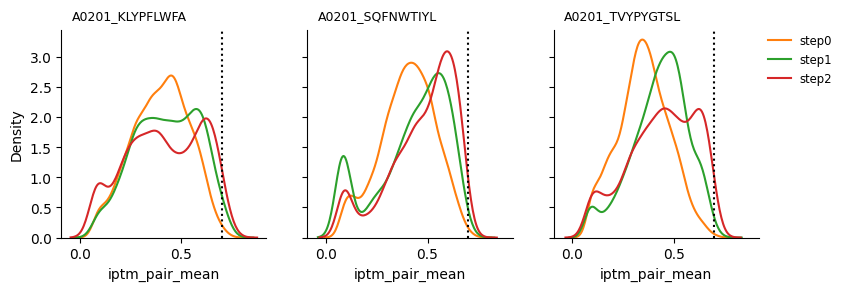

In [2]:
fig, axes = plt.subplots(1,3, figsize=(3*3,2.7), sharex=True, sharey=True)

steps = ['step0', 'step1', 'step2']

peptides = ['A0201_KLYPFLWFA', 'A0201_SQFNWTIYL', 'A0201_TVYPYGTSL']

# default seaborn/matplotlib palette, skipping the first color (blue)
colors = sns.color_palette()[1:len(steps)+1]


for cnt, peptide in enumerate(peptides):
    ax = axes[cnt]

    for step, color in zip(steps, colors):
        df1 = pd.read_csv(f'IMMREP25/{peptide}/{step}/output_alpha.csv')[['ID', 'iptm_pair_mean']]
        df2 = pd.read_csv(f'IMMREP25/{peptide}/{step}/output_beta.csv')[['ID', 'iptm_pair_mean']]
        df = pd.concat([df1, df2])
        sns.kdeplot(df, x='iptm_pair_mean', ax=ax, label=step, color=color)

        #df = pd.read_csv(f'TCR_motif_atlas/{peptide}/{step}/output-beta.csv')[['ID', 'iptm_pair_mean']]
        #sns.kdeplot(df, x='AF3_iptm_pair_mean', ax=ax, label=f'{step} (no prior)', color=color, linestyle=':')
        

        print(step, peptide, 0.7, len(df[df['iptm_pair_mean']>0.7]))

    ax.axvline(x=0.7, color='black', linestyle=':')
    sns.despine()
    ax.text(0.05, 1.05, f'{peptide}', transform=ax.transAxes, fontsize=9)

axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize='small', frameon=False)

    

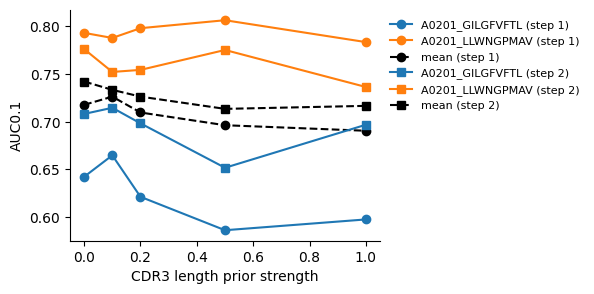

In [8]:
df = pd.read_csv('benchmark_MUT_v2/summary.csv')
#df = pd.read_csv('test/summary_top50.csv')

# marker per step, consistent across the whole figure
step_markers = {1: 'o', 2: 's'}   # add more if you have more steps

fig, ax = plt.subplots(figsize=(4, 3))

# stable color per epitope, shared across steps
epitopes = sorted(df['epitope'].unique())
colors = dict(zip(epitopes, plt.cm.tab10.colors))

for step, marker in step_markers.items():
    d = (df[df['step'] == step]
         .groupby(['mut', 'epitope'])[['auc', 'auc01']]
         .mean()
         .reset_index()
         .sort_values('mut'))

    # one colored line per epitope
    for epi in epitopes:
        sub = d[d['epitope'] == epi].sort_values('mut')
        if sub.empty:
            continue
        ax.plot(sub['mut'], sub['auc01'],
                marker=marker, color=colors[epi],
                label=f'{epi} (step {step})')

    # black dashed = mean across epitopes for this step
    mean_line = d.groupby('mut')['auc01'].mean().reset_index().sort_values('mut')
    ax.plot(mean_line['mut'], mean_line['auc01'],
            marker=marker, color='black', linestyle='--',
            label=f'mean (step {step})')

ax.set_xlabel('CDR3 length prior strength')          # <- replace with a meaningful label
ax.set_ylabel('AUC0.1')
ax.legend(fontsize=8, bbox_to_anchor=(1,1), frameon=False)
sns.despine()

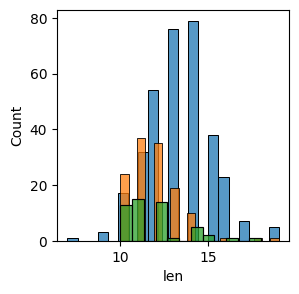

In [15]:
fig, ax = plt.subplots(1,1, figsize=(3,3))

for i in range(3):
    df = pd.read_csv(f'TCR_motif_atlas_decoy_correction/A0201_LLWNGPMAV/step{i}/top_tcrs_alpha.csv')
    df = df.sort_values(by='iptm_pair_mean', ascending = False)
    df['len'] = df['cdr3_TRA'].str.len()
    sns.histplot(df, x='len', ax=ax)

# AUC

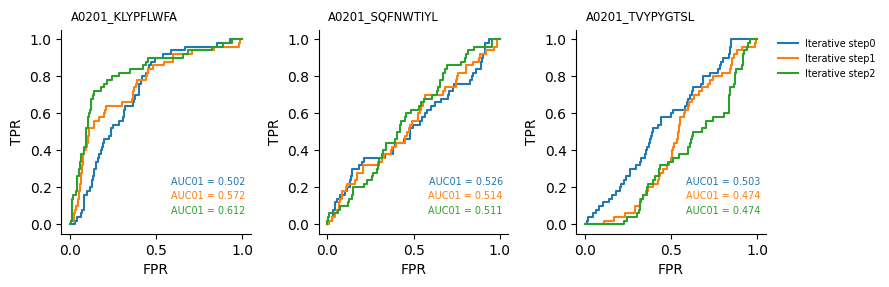

In [ ]:
epitopes = ['A0201_KLYPFLWFA', 'A0201_SQFNWTIYL', 'A0201_TVYPYGTSL']
steps = ['step0', 'step1', 'step2']

fig, axes = plt.subplots(1, len(epitopes), figsize=(9, 3))

for cnt, epitope in enumerate(epitopes):
    ax = axes[cnt]
    ax.text(0.05, 1.1, epitope, transform=ax.transAxes,
            va='top', ha='left', fontsize='small')

    # --- Experimental curve ---
    """
    df = pd.read_csv(
        f'../260512_TEMPO_motif_builder_test/{epitope}/TEMPO_train_exp.csv'
    )
    y_true, y_scores = df['Label'].values, df['score'].values
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
    line, = ax.plot(fpr, tpr, label='Experimental')
    ax.text(0.97, 0.3, f"AUC01 = {auc01:.3f}",
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize='x-small', color=line.get_color())
    """
    # --- One curve per step ---
    for i, s in enumerate(steps):
        df = pd.read_csv(
            f'IMMREP25/{epitope}/{s}/validation/validation_pred.csv'
        )
        y_true, y_scores = df['Label'].values, df['score'].values
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
        line, = ax.plot(fpr, tpr, label=f'Iterative {s}')
        ax.text(0.97, 0.23 - i * 0.07, f"AUC01 = {auc01:.3f}",
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize='x-small', color=line.get_color())

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize='x-small', frameon=False,
                bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()





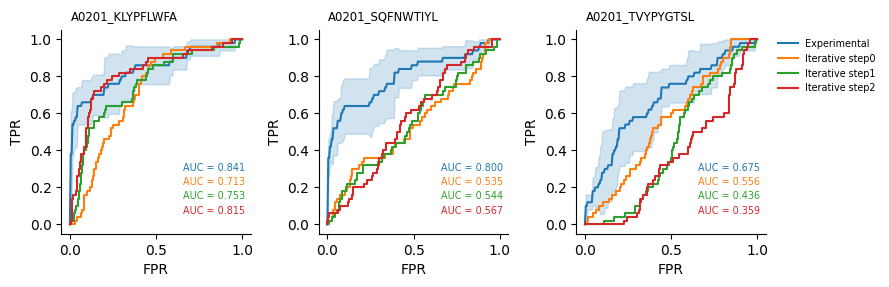

In [12]:
epitopes = ['A0201_KLYPFLWFA', 'A0201_SQFNWTIYL', 'A0201_TVYPYGTSL']
steps = ['step0', 'step1', 'step2']

METRIC = 'auc'          # 'auc' = full ROC AUC, 'auc01' = partial AUC at FPR<=0.1
_score = (lambda y, s: roc_auc_score(y, s, max_fpr=0.1)) if METRIC == 'auc01' else roc_auc_score
_label = 'AUC01' if METRIC == 'auc01' else 'AUC'

fig, axes = plt.subplots(1, len(epitopes), figsize=(9, 3))

for cnt, epitope in enumerate(epitopes):
    ax = axes[cnt]
    ax.text(0.05, 1.1, epitope, transform=ax.transAxes,
            va='top', ha='left', fontsize='small')

    # --- Experimental curve (5-fold CV: mean ROC + shaded error) ---
    grid = np.linspace(0, 1, 201)
    tprs, scores = [], []
    for k in range(1, 6):
        dfk = pd.read_csv(f'exp_data/{epitope}/exp_fold{k}_pred.csv')
        yk, sk = dfk['Label'].values, dfk['score'].values
        fpr, tpr, _ = roc_curve(yk, sk)
        tk = np.interp(grid, fpr, tpr); tk[0] = 0.0
        tprs.append(tk)
        scores.append(_score(yk, sk))
    tprs = np.vstack(tprs)
    mean_tpr, sd_tpr = tprs.mean(0), tprs.std(0)
    line, = ax.plot(grid, mean_tpr, label='Experimental')
    ax.fill_between(grid, np.clip(mean_tpr - sd_tpr, 0, 1), np.clip(mean_tpr + sd_tpr, 0, 1),
                    color=line.get_color(), alpha=0.2)
    ax.text(0.97, 0.3, f"{_label} = {np.mean(scores):.3f}",
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize='x-small', color=line.get_color())

    # --- One curve per step ---
    for i, s in enumerate(steps):
        df = pd.read_csv(f'IMMREP25/{epitope}/{s}/validation/validation_pred.csv')
        y_true, y_scores = df['Label'].values, df['score'].values
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        val = _score(y_true, y_scores)
        line, = ax.plot(fpr, tpr, label=f'Iterative {s}')
        ax.text(0.97, 0.23 - i * 0.07, f"{_label} = {val:.3f}",
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize='x-small', color=line.get_color())

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize='x-small', frameon=False,
                bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

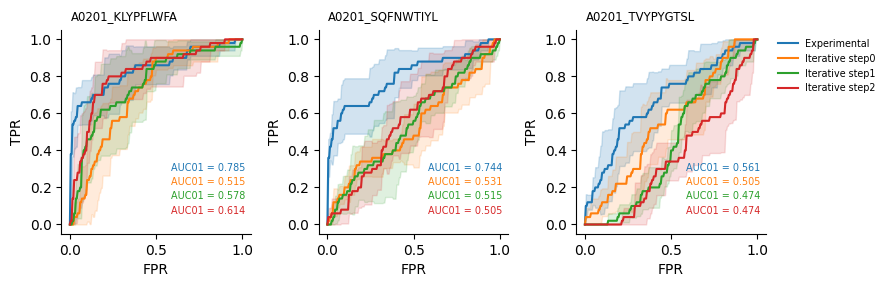

In [10]:
epitopes = ['A0201_KLYPFLWFA', 'A0201_SQFNWTIYL', 'A0201_TVYPYGTSL']
steps = ['step0', 'step1', 'step2']
grid = np.linspace(0, 1, 201)

def mean_roc_band(files):
    tprs, auc01s = [], []
    for f in files:
        df = pd.read_csv(f)
        y, s = df['Label'].values, df['score'].values
        fpr, tpr, _ = roc_curve(y, s)
        t = np.interp(grid, fpr, tpr); t[0] = 0.0
        tprs.append(t); auc01s.append(roc_auc_score(y, s, max_fpr=0.1))
    tprs = np.vstack(tprs)
    return tprs.mean(0), tprs.std(0), float(np.mean(auc01s))

fig, axes = plt.subplots(1, len(epitopes), figsize=(9, 3))
for cnt, epitope in enumerate(epitopes):
    ax = axes[cnt]
    ax.text(0.05, 1.1, epitope, transform=ax.transAxes, va='top', ha='left', fontsize='small')

    # --- Experimental (5-fold CV) ---
    m, sd, a01 = mean_roc_band([f'exp_data/{epitope}/exp_fold{k}_pred.csv' for k in range(1, 6)])
    line, = ax.plot(grid, m, label='Experimental')
    ax.fill_between(grid, np.clip(m - sd, 0, 1), np.clip(m + sd, 0, 1), color=line.get_color(), alpha=0.2)
    ax.text(0.97, 0.3, f"AUC01 = {a01:.3f}", transform=ax.transAxes, ha='right', va='bottom',
            fontsize='x-small', color=line.get_color())

    # --- Iterative steps (structural, SAME folds) ---
    for i, s in enumerate(steps):
        m, sd, a01 = mean_roc_band([f'exp_data/{epitope}/struct_{s}_fold{k}_pred.csv' for k in range(1, 6)])
        line, = ax.plot(grid, m, label=f'Iterative {s}')
        ax.fill_between(grid, np.clip(m - sd, 0, 1), np.clip(m + sd, 0, 1), color=line.get_color(), alpha=0.15)
        ax.text(0.97, 0.23 - i * 0.07, f"AUC01 = {a01:.3f}", transform=ax.transAxes, ha='right', va='bottom',
                fontsize='x-small', color=line.get_color())

    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize='x-small', frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine(); plt.tight_layout(); plt.show()
